In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250711-folde-testset-wCL',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])


round_metrics_df['config_name'] = round_metrics_df.config_name.apply(lambda x: {
    'FolDE-random': 'Random',
    'FolDE-Random-RandomForestCtrl': 'RandomForest',
    'FolDE-base': 'FolDE'
}.get(x, x))

Loading results for DMSs: {'KKA2_KLEPN_Melnikov_2014', 'MTHR_HUMAN_Weile_2021', 'MET_HUMAN_Estevam_2023', 'LGK_LIPST_Klesmith_2015', 'P53_HUMAN_Giacomelli_2018_Null_Nutlin', 'ADRB2_HUMAN_Jones_2020', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'PTEN_HUMAN_Mighell_2018', 'PPARG_HUMAN_Majithia_2016', 'AMIE_PSEAE_Wrenbeck_2017', 'SC6A4_HUMAN_Young_2021', 'S22A1_HUMAN_Yee_2023_activity', 'CAS9_STRP1_Spencer_2017_positive', 'P53_HUMAN_Giacomelli_2018_WT_Nutlin', 'MK01_HUMAN_Brenan_2016'}


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Random vs. RandomForest: t-test paired samples, P_val:nan t=nan
RandomForest vs. FolDE: t-test paired samples, P_val:5.148e-33 t=-1.555e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AMIE_PSEAE_Random vs. AMIE_PSEAE_RandomForest: t-test paired samples, P_val:nan t=nan
AMIE_PSEAE_RandomForest vs. AMIE_PSEAE_FolDE: t-test paired samples, P_val:7.414e-07 t=-1.205e+01
CAS9_STRP1_Random vs. CAS9_STRP1_RandomForest: t-test paired samples, P_val:nan t=nan
CAS9_STRP1_RandomForest vs. CAS9_STRP1_FolDE: t-test paired samples, P_val:8.674e-01 t=1.718e-01
KCNJ2_MOUSE_Random vs. KCNJ2_MOUSE_RandomForest: t-test paired samples, P_val:nan t=nan
KCNJ2_MOUSE_RandomFor

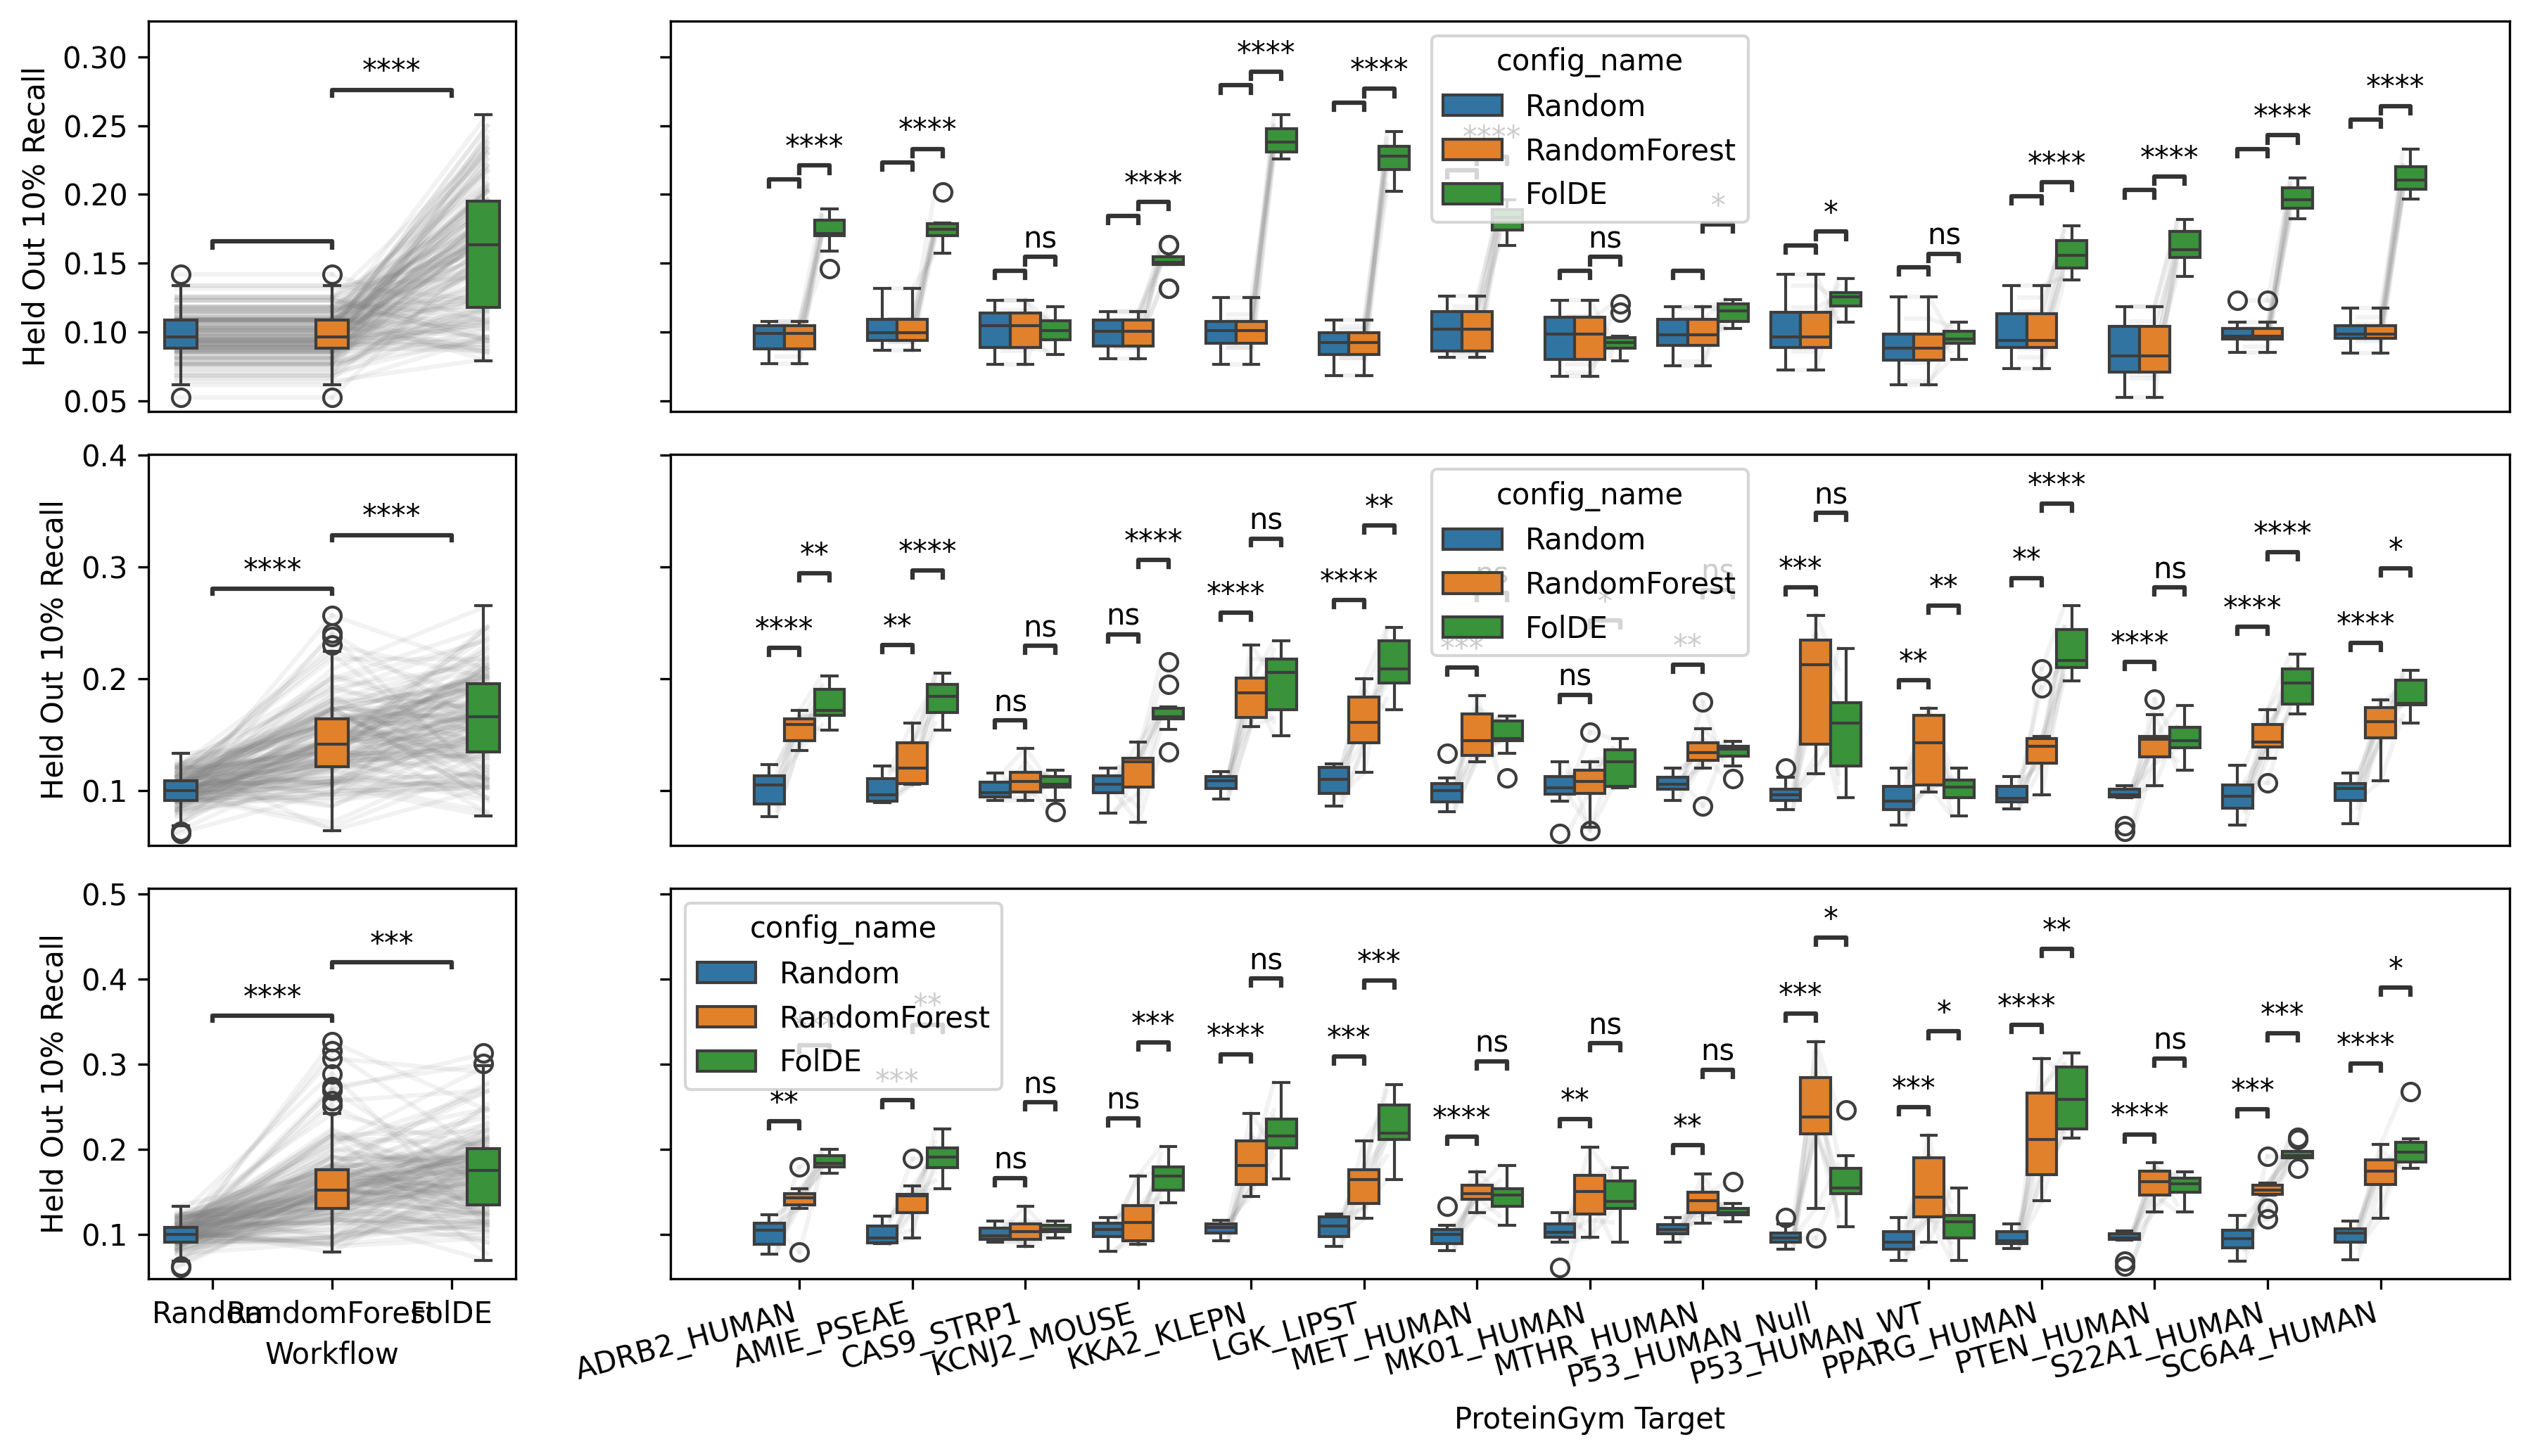

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import scipy.stats as stats

# method1 = 'FolDE-Random-RandomForestCtrl'
methods = [
    'Random',
    'RandomForest',
    'FolDE'
]

METRIC = 'held_out_10pct_recall'  # 'best_activity_this_round'  # held_out_activity_spearman
LINE_ALPHA = 0.1

YRANGE = (0.0, 0.1)

def plot_aggregate_comparison(ax, data_df):
    sns.boxplot( # stripplot
        data=data_df,
        x="config_name",
        y=METRIC,
        hue="config_name",
        dodge=True,
        # jitter=True,
        # alpha=0.7,
        order=methods,
        hue_order=methods,
        ax=ax
    )

    for ii, (method1, method2) in enumerate(zip(methods[:-1], methods[1:])):
        for sim_id in data_df['sim_num'].unique():
            subset = data_df[
                (data_df['sim_num'] == sim_id)
            ].set_index('config_name')
            y1 = subset.loc[method1, METRIC]
            y2 = subset.loc[method2, METRIC]
            # Get the x position for this dms_shortname
            # Get the x positions for the two hues (dodge)
            ax.plot(
                [-0.3 + ii* 1.3, 1.0 + ii * 1.3],
                [y1, y2],
                color='gray',
                alpha=LINE_ALPHA,
                zorder=1
            )

    ax1_pairs = [
        ((mleft,), (mright,)) for mleft, mright in zip(methods[:-1], methods[1:])
    ]

    # ax1_pairs = [
    #     ((methods[0], ), (methods[1], )),
    #     ((methods[1], ), (methods[2], )),
    # ]
    annot1 = Annotator(
        ax,
        ax1_pairs,
        data=data_df,
        x='config_name',
        y=METRIC,
        hue="config_name",
        order=methods,
        hue_order=methods
    )
    annot1.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
    annot1.apply_test()
    annot1.annotate()

    ax.set_ylabel('')
    ax.set_xlabel('')


def plot_breakdown_comparison(ax, data_df):
    sns.boxplot(
        data=data_df,
        x="dms_shortname",
        y=METRIC,
        hue="config_name",
        dodge=True,
        # jitter=True,
        # alpha=0.7,
        order=ordered_dms,
        hue_order=methods,
        ax=ax
    )

    pairs = []

    # Connect the two config points for each dms_shortname
    for dms in ordered_dms:
        for ii, (method1, method2) in enumerate(zip(methods[:-1], methods[1:])):
            pairs.append(
                ((dms, method1), (dms, method2))
            )

            for sim_id in data_df['sim_num'].unique():
                subset = data_df[
                    (data_df['dms_shortname'] == dms) &
                    (data_df['sim_num'] == sim_id)
                ].set_index('config_name')
                y1 = subset.loc[method1, METRIC]
                y2 = subset.loc[method2, METRIC]
                # Get the x position for this dms_shortname
                x_pos = ordered_dms.index(dms)
                # Get the x positions for the two hues (dodge)
                offsets = [-0.2 + ii * 0.2, 0.0 + ii * 0.2]  # adjust if your dodge is different
                ax.plot(
                    [x_pos + offsets[0], x_pos + offsets[1]],
                    [y1, y2],
                    color='gray',
                    alpha=LINE_ALPHA,
                    zorder=1
                )


    annot = Annotator(
        ax,
        pairs,
        data=data_df,
        x="dms_shortname",
        y=METRIC,
        hue="config_name",
        comparisons_correction='bonferroni',
        order=ordered_dms,
        hue_order=methods
    )
    annot.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
    annot.apply_test()
    annot.annotate()

    ax.set_ylabel('')
    ax.set_xlabel('')




fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 7), dpi=300, width_ratios=(1,5), sharey='row')

for ROUND, (leftax, rightax) in [(1, (ax1, ax2)), (2, (ax3, ax4)), (3, (ax5, ax6))]:
    comparison_df = round_metrics_df.copy()
    comparison_df = comparison_df[
        comparison_df.config_name.isin(methods) & (round_metrics_df.round_num == ROUND)
    ].sort_values(['dms_id', 'config_name', 'sim_num']).copy()

    # Sort dms_shortname for consistent x-axis order
    ordered_dms = sorted(comparison_df['dms_shortname'].unique())

    plot_aggregate_comparison(leftax, comparison_df)
    plot_breakdown_comparison(rightax, comparison_df)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks([])
# for ax in [ax2, ax4, ax6]:
#     ax.set_yticks([])
# for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
#     ax.set_ylim(YRANGE[0], YRANGE[1])
# for ax in [ax4, ax6]:
#     ax.set_legend(False)

for ax in [ax1, ax3, ax5]:
    if METRIC == 'held_out_1pct_recall':
        ax.set_ylabel('Held Out 1% Recall')
    elif METRIC == 'held_out_10pct_recall':
        ax.set_ylabel('Held Out 10% Recall')
    else:
        ax.set_ylabel(METRIC)

ax5.set_xlabel('Workflow')
ax6.set_xlabel('ProteinGym Target')

# plt.title(f'Performance Difference At Round {ROUND}')
plt.xticks(rotation=15, ha="right")
plt.legend(title='config_name')
plt.tight_layout()
plt.show()


In [3]:
# 1. Pivot the DataFrame to get paired values side by side
for metric in ['held_out_1pct_recall', 'held_out_10pct_recall']:
    for round_num in [1, 2, 3, 'allrounds']:
        method1 = 'RandomForest'
        method2 = 'FolDE'
        if round_num == 'allrounds':
            subset_df = round_metrics_df.copy()
        else:
            subset_df = round_metrics_df[round_metrics_df.round_num == round_num]
        paired = subset_df.pivot_table(
            index=['dms_id', 'sim_num'],  # or add more columns if needed for unique pairing
            columns='config_name',
            values=metric
        )

        t_stat, p_value = stats.ttest_rel(paired[method1], paired[method2])
        means = paired.mean(axis=0)

        print(f"{metric} R{round_num} {method1}: {means[method1]:.3f}, {method2}: {means[method2]:.3f}: up = {100.0*(means[method2] - means[method1])/means[method1]:.3f}% (Paired t-test: t = {t_stat:.3f}, p = {p_value:.3g})")


# # 2. Drop any rows with missing values (i.e., where a pair is incomplete)
# paired = paired.dropna(subset=[method1, method2])

held_out_1pct_recall R1 RandomForest: 0.009, FolDE: 0.020: up = 115.514% (Paired t-test: t = -4.479, p = 1.49e-05)
held_out_1pct_recall R2 RandomForest: 0.016, FolDE: 0.020: up = 22.450% (Paired t-test: t = -1.266, p = 0.208)
held_out_1pct_recall R3 RandomForest: 0.022, FolDE: 0.020: up = -10.280% (Paired t-test: t = 0.788, p = 0.432)
held_out_1pct_recall Rallrounds RandomForest: 0.024, FolDE: 0.025: up = 4.900% (Paired t-test: t = -0.486, p = 0.628)
held_out_10pct_recall R1 RandomForest: 0.098, FolDE: 0.160: up = 63.616% (Paired t-test: t = -15.553, p = 5.15e-33)
held_out_10pct_recall R2 RandomForest: 0.145, FolDE: 0.164: up = 13.107% (Paired t-test: t = -5.115, p = 9.49e-07)
held_out_10pct_recall R3 RandomForest: 0.158, FolDE: 0.173: up = 9.652% (Paired t-test: t = -3.596, p = 0.000439)
held_out_10pct_recall Rallrounds RandomForest: 0.152, FolDE: 0.176: up = 15.318% (Paired t-test: t = -6.747, p = 3.12e-10)


In [9]:
method1 = 'RandomForest'
method2 = 'FolDE'
if round_num == 'allrounds':
    subset_df = round_metrics_df.copy()
else:
    subset_df = round_metrics_df[round_metrics_df.round_num == round_num]
melted_subset_df = subset_df[['config_name', 'dms_id', 'sim_num', 'round_num', 'held_out_1pct_recall', 'held_out_10pct_recall']].melt(id_vars=['config_name', 'dms_id', 'sim_num', 'round_num'], var_name='metric_name', value_name='metric_value')
paired = melted_subset_df.pivot_table(
    index=['dms_id', 'metric_name', 'round_num', 'sim_num'],  # or add more columns if needed for unique pairing
    columns='config_name',
    values='metric_value'
)
paired

config_name                                                        FolDE  \
dms_id                 metric_name           round_num sim_num             
ADRB2_HUMAN_Jones_2020 held_out_10pct_recall 1         0        0.171795   
                                                       1        0.171795   
                                                       2        0.189744   
                                                       3        0.184615   
                                                       4        0.158974   
...                                                                  ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5        0.034483   
                                                       6        0.000000   
                                                       7        0.017241   
                                                       8        0.000000   
                                                       9        0.051724   

config_name                                                     FolDE-15b-embeddings  \
dms_id                 metric_name           round_num sim_num                         
ADRB2_HUMAN_Jones_2020 held_out_10pct_recall 1         0                    0.171795   
                                                       1                    0.171795   
                                                       2                    0.189744   
                                                       3                    0.184615   
                                                       4                    0.158974   
...                                                                              ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5                    0.034483   
                                                       6                    0.000000   
                                                       7                    0.017241   
                                                       8                    0.000000   
                                                       9                    0.086207   

config_name                                                     FolDE-600m-embeddings  \
dms_id                 metric_name           round_num sim_num                          
ADRB2_HUMAN_Jones_2020 held_out_10pct_recall 1         0                     0.171795   
                                                       1                     0.171795   
                                                       2                     0.189744   
                                                       3                     0.184615   
                                                       4                     0.158974   
...                                                                               ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5                     0.034483   
                                                       6                     0.017241   
                                                       7                     0.000000   
                                                       8                     0.000000   
                                                       9                     0.051724   

config_name                                                     FolDE-650m-embeddings  \
dms_id                 metric_name           round_num sim_num                          
ADRB2_HUMAN_Jones_2020 held_out_10pct_recall 1         0                     0.171795   
                                                       1                     0.171795   
                                                       2                     0.189744   
                                                       3                     0.184615   
                                                       4                     0.158974   
...                                                                               ...

In [10]:
t_stat, p_value = stats.ttest_rel(paired[method1], paired[method2])
means = paired.mean(axis=0)

print(f"All metrics all rounds {method1}: {means[method1]:.3f}, {method2}: {means[method2]:.3f}: up = {100.0*(means[method2] - means[method1])/means[method1]:.3f}% (Paired t-test: t = {t_stat:.3f}, p = {p_value:.3g})")


All metrics all rounds RandomForest: 0.088, FolDE: 0.100: up = 13.925% (Paired t-test: t = -10.633, p = 1.19e-25)
